# Business Analysis

This notebook focuses on business-level insights derived from the e-commerce dataset. It examines:

- product performance
- customer value and segmentation
- geographic performance
- time-based revenue trends
- discount effectiveness
- customer satisfaction and delivery experience

In [4]:
import pandas as pd
# load the df dataframe from the pickle file that has been saved in the previous notebook
df = pd.read_pickle("df.pkl")

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,quarter,day_of_week
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1,Saturday
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,1,Sunday
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,1,Monday
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,1,Tuesday
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,1,Wednesday


## Section 1: Product Analysis

This section addresses the following questions to evaluate product performance:

- Which product categories generate the highest sales volume?
- Which categories contribute the most revenue?
- Which categories have the highest average order value?
- Which categories have the highest average unit price?
- Which categories receive the largest discounts?

In [5]:
category_revenue = (
    df.groupby('product_category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

category_revenue





product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

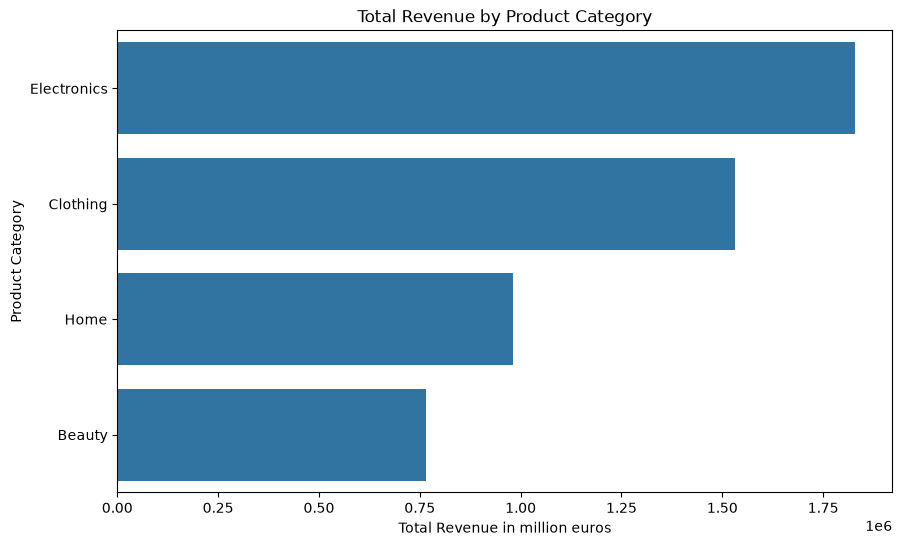

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue in million euros')
plt.ylabel('Product Category')
plt.show()

In [11]:
category_volume = (
    df.groupby('product_category')['quantity']
    .sum()
    .sort_values(ascending=False)
)

category_volume

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64

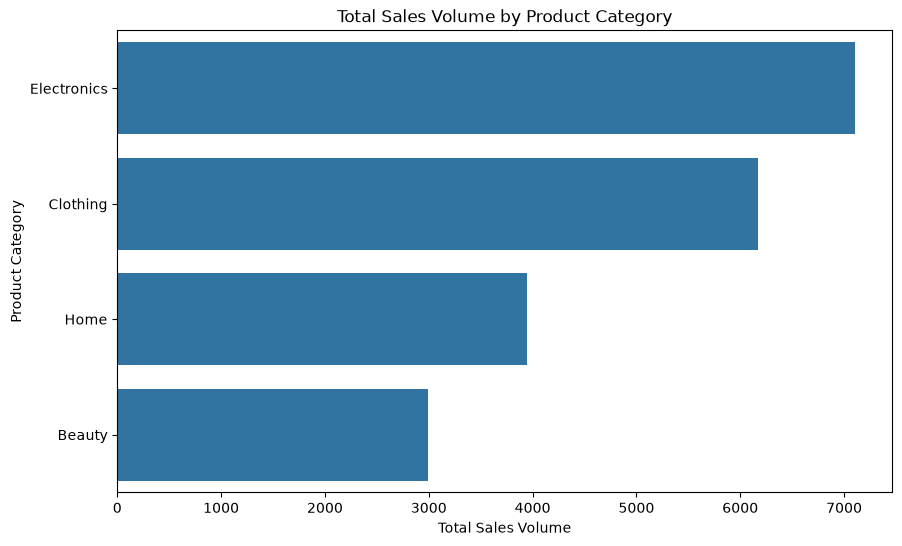

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_volume.values,
    y=category_volume.index
)
plt.title('Total Sales Volume by Product Category')
plt.xlabel('Total Sales Volume')
plt.ylabel('Product Category')
plt.show()

In [14]:
category_orders = (
    df.groupby('product_category')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

category_orders

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: order_id, dtype: int64

In [15]:
category_aov = (
    df.groupby("product_category")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
)

category_aov["AOV"] = (
    category_aov["revenue"] /
    category_aov["orders"]
)

category_aov.sort_values("AOV", ascending=False)

,revenue,orders,AOV
product_category,,,
Beauty,765860.88,723,1059.281992
Electronics,1829899.22,1777,1029.768835
Home,982083.92,969,1013.502497
Clothing,1531931.72,1531,1000.608570


**Product Performance Table**

In [ ]:

product_performance = (
    df.groupby("product_category")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        avg_price=("unit_price", "mean"),
        avg_discount=("discount", "mean"),
        avg_rating=("customer_rating", "mean"),
        avg_delivery_days=("delivery_days", "mean")
    )
)

product_performance["AOV"] = (
    product_performance["revenue"] /
    product_performance["orders"]
)

product_performance.sort_values(
    "revenue",
    ascending=False
)

,revenue,orders,units_sold,avg_price,avg_discount,avg_rating,avg_delivery_days,AOV
product_category,,,,,,,,
Electronics,1829899.22,1777,7109,314.902656,0.176652,2.951097,6.070343,1029.768835
Clothing,1531931.72,1531,6171,304.010901,0.184259,3.005095,6.118877,1000.608570
Home,982083.92,969,3949,306.257730,0.178266,2.940660,6.145511,1013.502497
Beauty,765860.88,723,2995,304.712891,0.181425,3.008990,6.201936,1059.281992


## Key Business Insights

### Electronics is the strongest category overall

- It generated the highest revenue, totaling €1,829,899.22.
- It also produced the highest total sales volume, reaching 7,109 units.
- It recorded the largest number of orders (1,777), making it the clear driver of business revenue and demand.
- This suggests that Electronics should remain a top priority for inventory planning, promotional investment, and marketing efforts.

### Clothing is the second-largest category and remains highly important

- It generated €1,531,931.72 in revenue and recorded 1,531 orders.
- It sold 6,171 units, indicating strong demand and a broad customer base.
- Its performance remains closely aligned with Electronics, which highlights its importance as a secondary revenue stream.
- Clothing is likely a key category for repeat purchases and customer retention.

### Beauty has the highest average order value, despite lower total revenue

- Beauty’s average order value is €1,059.28, slightly higher than Electronics at €1,029.77.
- This suggests that Beauty customers spend more per purchase even though the category sells fewer units.
- Premium positioning, bundles, and targeted upselling could strengthen performance in this segment.

### Home is a stable mid-tier category

- It generated €982,083.92 in revenue and 969 orders.
- Its AOV is approximately €1,013.50, which indicates healthy but not leading performance.
- Home appears to be a dependable category with moderate demand rather than a top growth driver.

### Category differences are driven more by demand and pricing than by discount or delivery speed

- Average discount rates are relatively consistent across categories, ranging from approximately 17.7% to 18.4%.
- Average delivery times are also similar, around 6.1 to 6.2 days.
- This suggests that revenue differences are more closely linked to product demand, order volume, and pricing strategy than to operational variation.

## Section 2: Customer Analysis

This section explores customer value, purchasing frequency, and the distribution of revenue across the customer base.

In [ ]:
# Calculate total revenue, number of orders, and total units purchased per customer, then compute average order value (AOV)

customer_revenue = (
    df.groupby("customer_id")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
)

customer_revenue["AOV"] = (
    customer_revenue["revenue"] /
    customer_revenue["orders"]
)

# Display the top 10 customers by revenue
top_customers = customer_revenue.sort_values(
    "revenue",
    ascending=False
).head(10)

top_customers

,revenue,orders,units,AOV
customer_id,,,,
1663,17680.69,14,63,1262.906429
1955,16265.15,10,47,1626.515000
1675,15036.46,11,55,1366.950909
1276,15023.71,11,50,1365.791818
1647,14894.97,11,45,1354.088182
1804,14330.98,10,44,1433.098000
1193,14151.65,7,40,2021.664286
1836,14110.78,9,47,1567.864444
1957,13956.95,12,57,1163.079167


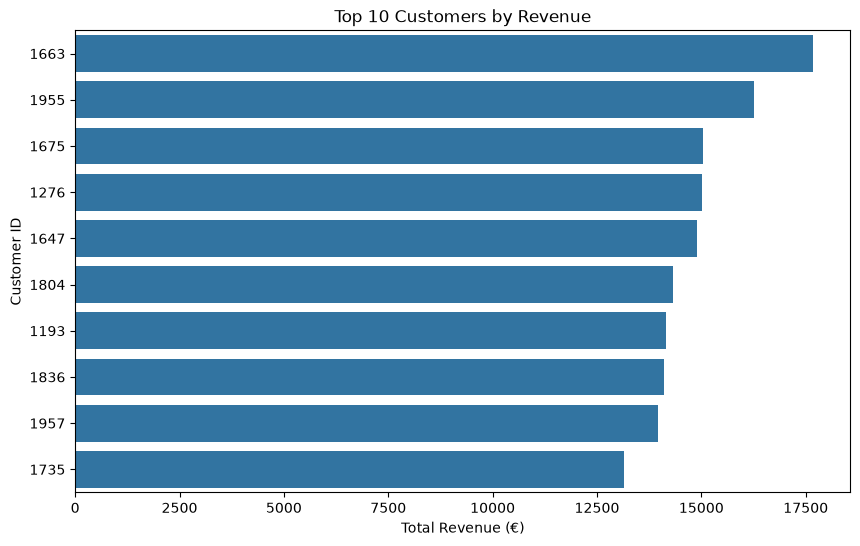

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_customers["revenue"],
    y=top_customers.index.astype(str)

)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue (€)')
plt.ylabel('Customer ID')
plt.show()

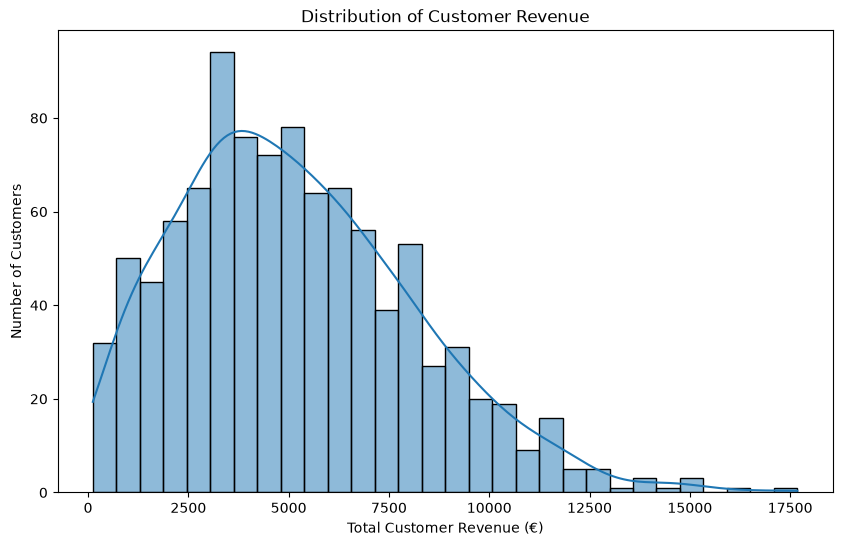

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_revenue['revenue'],
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Revenue')
plt.xlabel('Total Customer Revenue (€)')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# To explore the distribution of numbers of orders placed by customers by generating a new dataframe customer_orders 
customer_orders = (
    df.groupby('customer_id')['order_id']
    .nunique()
)
# customer_orders 
customer_orders.describe()

count    989.000000
mean       5.055612
std        2.325258
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       14.000000
Name: order_id, dtype: float64

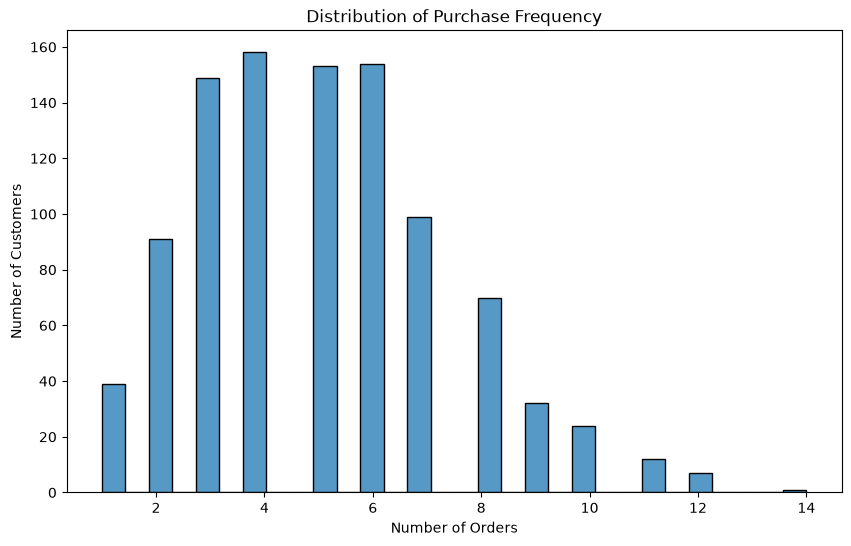

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_orders,
    bins=30
)

plt.title('Distribution of Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# RFM analysis to quantitatily measure customer value and segment customers based on their purchasing behavior 
analysis_date = df["order_date"].max() + pd.Timedelta(days=1) # the analysis date is set to one day after the most recent order date in the dataset

rfm = (
    df.groupby("customer_id")
    .agg(
        recency=("order_date", lambda x: (analysis_date - x.max()).days), # recency is calculated as the number of days since the customer's last purchase
        frequency=("order_id", "nunique"), # frequency is calculated as the number of unique orders placed by the customer
        monetary=("revenue", "sum") # monetary is calculated as the total revenue generated by the customer
    )
)

rfm.head()

,recency,frequency,monetary
customer_id,,,
1000,66,9,6905.58
1001,2018,6,3959.74
1002,2084,4,1579.67
1003,3184,2,2304.44
1004,3573,5,6073.85


In [ ]:
# Segment customers into four groups based on their monetary value using quartiles so specific marketing techniques can be used to each segment 
rfm["value_segment"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

rfm.head()


,recency,frequency,monetary,value_segment
customer_id,,,,
1000,66,9,6905.58,High
1001,2018,6,3959.74,Medium
1002,2084,4,1579.67,Low
1003,3184,2,2304.44,Low
1004,3573,5,6073.85,High


In [35]:
rfm["value_segment"].value_counts()

value_segment
Low          248
Medium       247
High         247
Very High    247
Name: count, dtype: int64

**Customer analysis findings**

A small group of customers is highly valuable. The top 10 customers each generated roughly €13k–€17.7k in revenue, with 7–14 orders each, showing that a loyal high-value segment drives a meaningful share of revenue.

Purchase frequency is healthy that the average customer orders about 5 times, with a median of 5 and a max of 14, indicating solid repeat-buying behavior.

Customer value is fairly balanced across the base. The RFM value segments are split almost evenly across Low, Medium, High, and Very High, suggesting the business has both a broad customer base and a meaningful premium segment.

Overall, the business has a steady repeat-purchase base plus a smaller group of very high-value customers that should be prioritized for retention and upselling.

**Session 3: Geographic Analysis**

In [37]:
region_performance = (
    df.groupby("region")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_rating=("customer_rating", "mean")
    )
)

region_performance["AOV"] = (
    region_performance["revenue"] /
    region_performance["orders"]
)

region_performance.sort_values(
    "revenue",
    ascending=False
)

,revenue,orders,units,avg_delivery_days,avg_rating,AOV
region,,,,,,
West,1345582.16,1289,5260,6.082234,2.961521,1043.896168
North,1281508.45,1276,5164,6.118339,2.993182,1004.316967
South,1246640.90,1208,4884,6.173013,2.967798,1031.987500
East,1236044.23,1227,4916,6.104319,2.973187,1007.371011


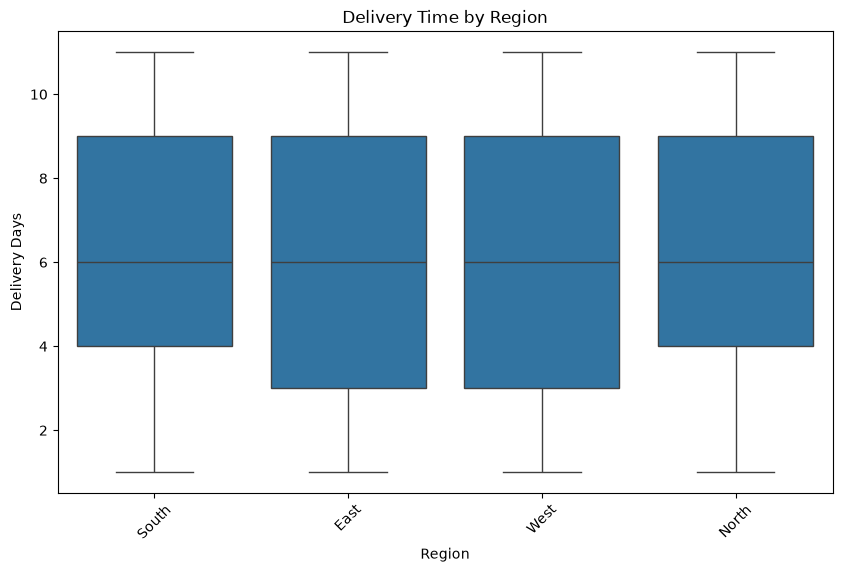

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="region",
    y="delivery_days"
)

plt.title("Delivery Time by Region")
plt.xlabel("Region")
plt.ylabel("Delivery Days")
plt.xticks(rotation=45)
plt.show()

**Geographical analysis findings**

West is the strongest region overall. It generates the highest revenue at €1.35 million and the most orders (1,289), making it the leading market

North is very close behind West, with revenue of €1.28 million and a similar order count (1,276), while South and East are smaller but still important contributors.

Delivery performance is fairly consistent across regions, with average delivery times ranging only from about 6.08 to 6.17 days, so logistics is not a major regional differentiator.

Customer satisfaction is also similar across regions, with average ratings around 2.96–2.99, indicating no major quality gap by geography.

Overall the business is geographically balanced, despite that West is the clear leader.

**Session 4: Time Series Analysis**

In [54]:
# change the data types of the column year, month, quarter, and day of week from numbers to categories 
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('category')
df['quarter'] = df['quarter'].astype('category')
df['day_of_week'] = df['day_of_week'].astype('category')



*Yearly Performance Analysis*

In [ ]:

yearly_sales = (
    df.groupby("year")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        customers=("customer_id", "nunique")
    )
)

yearly_sales["AOV"] = (
    yearly_sales["revenue"] /
    yearly_sales["orders"]
)

yearly_sales


,revenue,orders,units_sold,customers,AOV
year,,,,,
2022,371824.30,365,1469,294,1018.696712
2023,365915.79,365,1497,306,1002.509014
2024,363209.13,366,1489,309,992.374672
2025,349802.33,365,1410,307,958.362548
2026,386369.69,365,1478,303,1058.547096
2027,386151.91,365,1546,294,1057.950438
2028,376844.80,366,1476,299,1029.630601
2029,359239.24,365,1472,317,984.217096
2030,387884.46,365,1500,301,1062.697151


In [56]:
# year on year growth rate 
yearly_sales["revenue_growth"] = (
    yearly_sales["revenue"].pct_change() * 100
)

yearly_sales["order_growth"] = (
    yearly_sales["orders"].pct_change() * 100
)

yearly_sales["AOV_growth"] = (
    yearly_sales["AOV"].pct_change() * 100
)

yearly_sales

,revenue,orders,units_sold,customers,AOV,revenue_growth,order_growth,AOV_growth
year,,,,,,,,
2022,371824.30,365,1469,294,1018.696712,NaN,NaN,NaN
2023,365915.79,365,1497,306,1002.509014,-1.589060,0.000000,-1.589060
2024,363209.13,366,1489,309,992.374672,-0.739695,0.273973,-1.010898
2025,349802.33,365,1410,307,958.362548,-3.691207,-0.273224,-3.427347
2026,386369.69,365,1478,303,1058.547096,10.453721,0.000000,10.453721
2027,386151.91,365,1546,294,1057.950438,-0.056366,0.000000,-0.056366
2028,376844.80,366,1476,299,1029.630601,-2.410220,0.273973,-2.676859
2029,359239.24,365,1472,317,984.217096,-4.671833,-0.273224,-4.410660
2030,387884.46,365,1500,301,1062.697151,7.973856,0.000000,7.973856


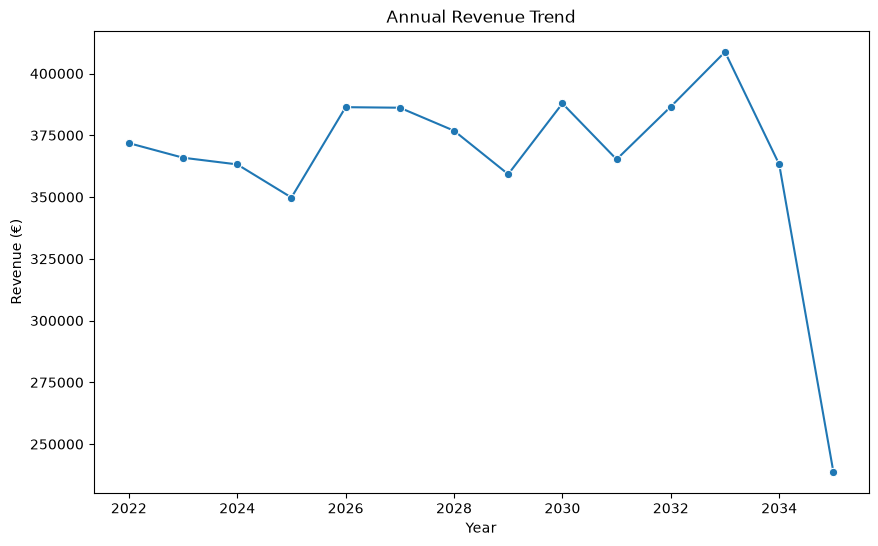

In [60]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_sales,
    x=yearly_sales.index,
    y="revenue",
    marker="o"
)

plt.title("Annual Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue (€)")
plt.show()

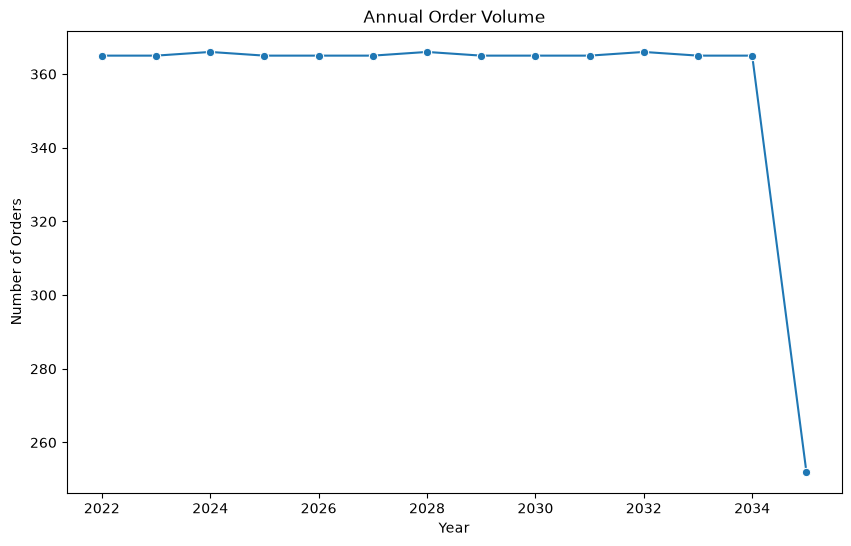

In [58]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_sales,
    x=yearly_sales.index,
    y="orders",
    marker="o"
)

plt.title("Annual Order Volume")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.show()

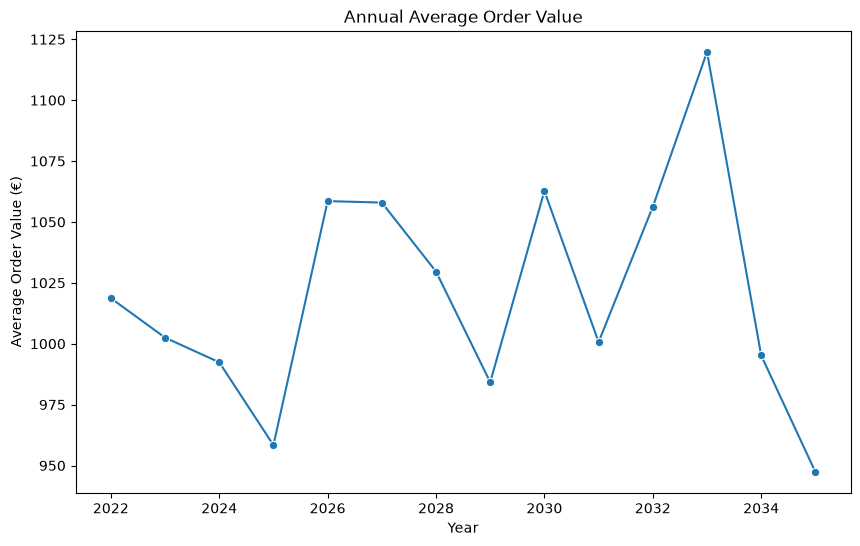

In [61]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_sales,
    x=yearly_sales.index,
    y="AOV",
    marker="o"
)

plt.title("Annual Average Order Value")
plt.xlabel("Year")
plt.ylabel("Average Order Value (€)")
plt.show()

Key findings:
- Annual revenue changes considerably across years, with sharp declines in some years, indicating that overall sales performance is not stable over time.
- Despite these revenue swings, annual order volume remains relatively consistent, suggesting that fluctuations are driven less by the number of orders and more by changes in order value, customer mix, or product mix.
- Average order value also varies noticeably across years, ranging from lower to higher levels, which suggests that pricing and basket composition influence revenue more than order count alone.
- The sharp drop in the most recent year likely reflects a significant decline in demand, customer base, or transaction size, and should be examined further to understand whether this is a real trend or a data artifact.
- Overall, the business appears to have stable order frequency but volatile revenue outcomes, which points to the importance of value per order and product mix in driving yearly performance.


*Monthly Performance Analysis*

In [62]:
monthly_sales = (
    df.groupby(["year", "month"])
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum")
    )
    .reset_index()
)

monthly_sales["AOV"] = (
    monthly_sales["revenue"] /
    monthly_sales["orders"]
)

monthly_sales.head()

,year,month,revenue,orders,units_sold,AOV
0,2022,1,35624.89,31,149,1149.190000
1,2022,2,29908.89,28,100,1068.174643
2,2022,3,30309.28,31,128,977.718710
3,2022,4,30781.96,30,123,1026.065333
4,2022,5,41629.24,31,145,1342.878710


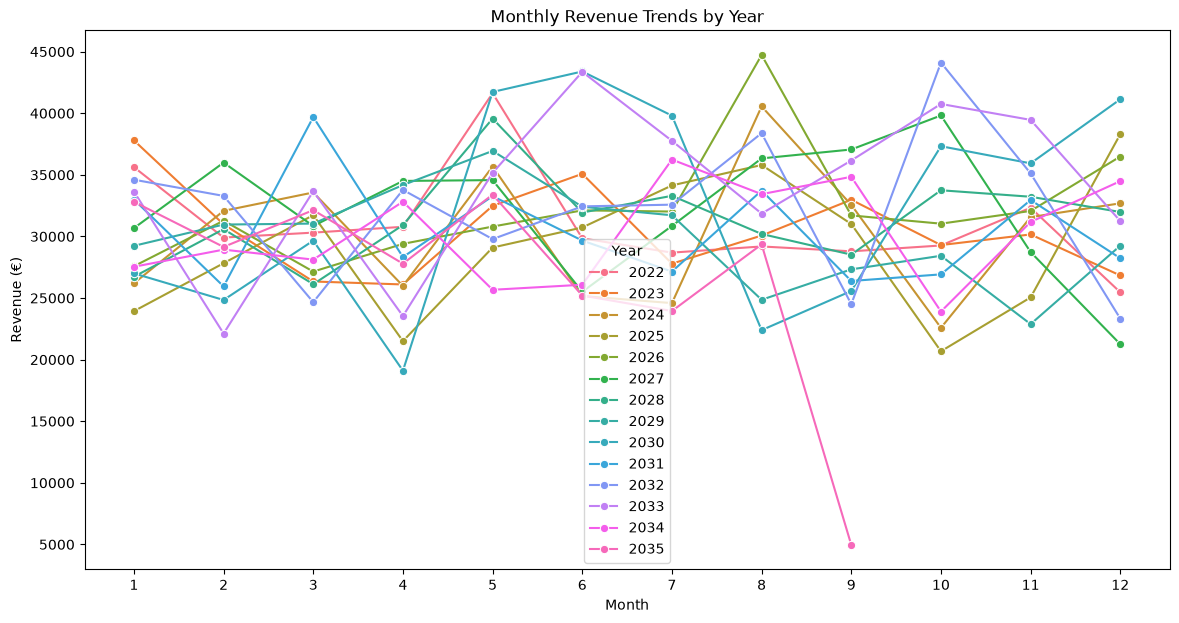

In [64]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    hue="year",
    marker="o"
)

plt.title("Monthly Revenue Trends by Year")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.show()

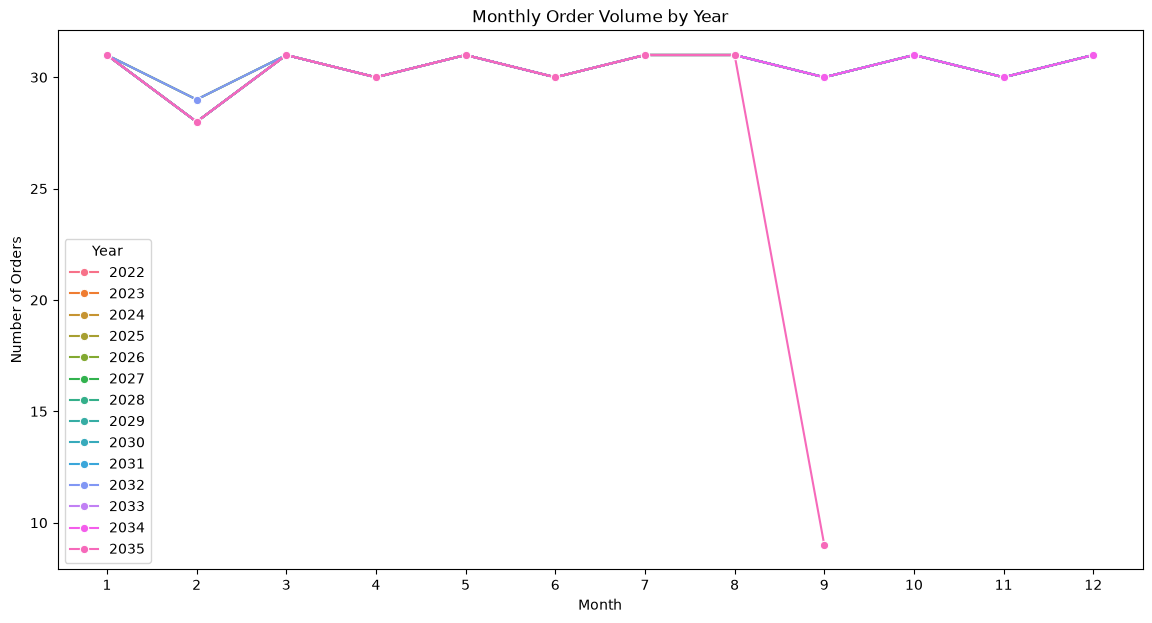

In [65]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="orders",
    hue="year",
    marker="o"
)

plt.title("Monthly Order Volume by Year")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.show()

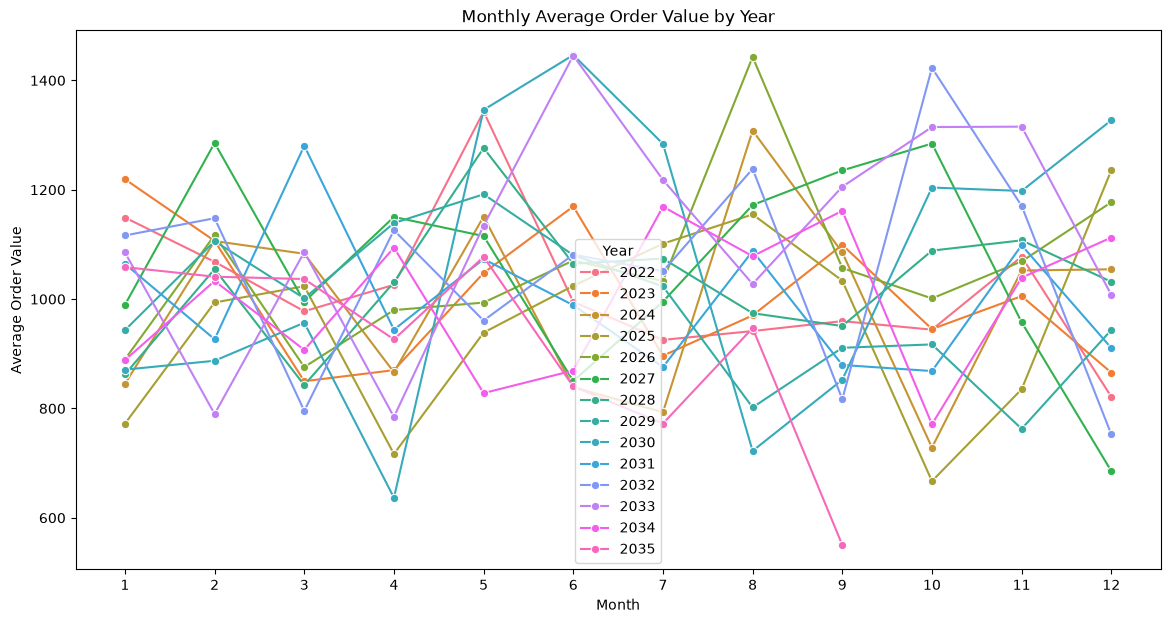

In [66]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="AOV",
    hue="year",
    marker="o"
)

plt.title("Monthly Average Order Value by Year")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.show()

In [67]:
seasonality = (
    monthly_sales.groupby('month')
    .agg(
        avg_revenue=('revenue', 'mean'),
        avg_orders=('orders', 'mean'),
        avg_AOV=('AOV', 'mean')
    )
)

seasonality

,avg_revenue,avg_orders,avg_AOV
month,,,
1,30455.351429,31.000000,982.430691
2,29563.588571,28.214286,1047.401274
3,30360.751429,31.000000,979.379078
4,28479.654286,30.000000,949.321810
5,34269.467857,31.000000,1105.466705
6,31638.684286,30.000000,1054.622810
7,31469.337143,31.000000,1015.139908
8,32919.627143,31.000000,1061.923456
9,28740.579286,28.500000,985.531698


In [68]:
overall_monthly_average = seasonality["avg_revenue"].mean()

seasonality["seasonality_index"] = (
    seasonality["avg_revenue"] /
    overall_monthly_average
)

seasonality

,avg_revenue,avg_orders,avg_AOV,seasonality_index
month,,,,
1,30455.351429,31.000000,982.430691,0.983269
2,29563.588571,28.214286,1047.401274,0.954478
3,30360.751429,31.000000,979.379078,0.980214
4,28479.654286,30.000000,949.321810,0.919482
5,34269.467857,31.000000,1105.466705,1.106410
6,31638.684286,30.000000,1054.622810,1.021473
7,31469.337143,31.000000,1015.139908,1.016006
8,32919.627143,31.000000,1061.923456,1.062829
9,28740.579286,28.500000,985.531698,0.927906


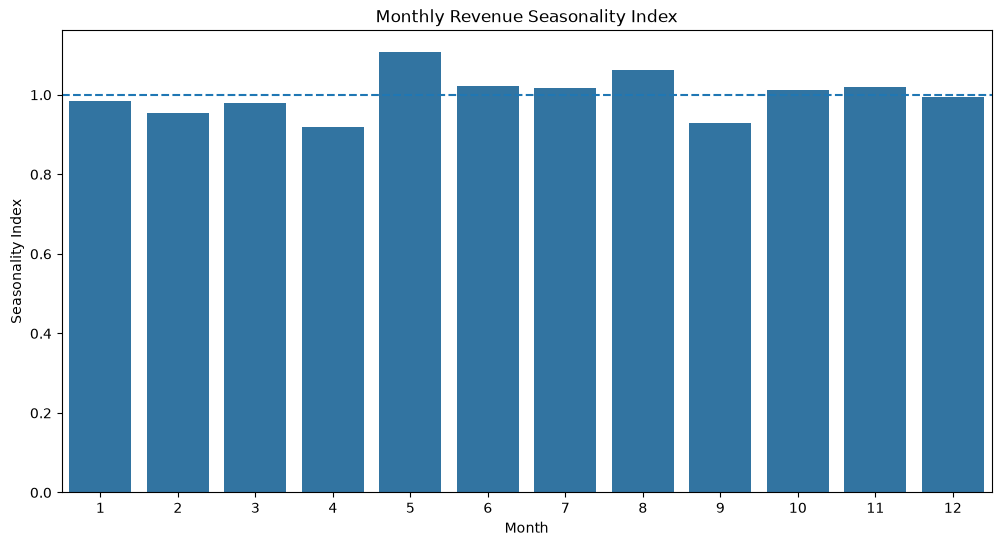

In [70]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=seasonality.index,
    y=seasonality["seasonality_index"]
)

plt.axhline(
    1,
    linestyle="--"
)

plt.title("Monthly Revenue Seasonality Index")
plt.xlabel("Month")
plt.ylabel("Seasonality Index")
plt.show()

Key findings:
- Monthly revenue shows a clear seasonal pattern, with some months performing noticeably above and below the overall average.
- The strongest months are around May and August, where revenue and AOV are both higher than the rest of the year, suggesting stronger customer demand and larger basket values during those periods.
- The weakest months are April and September, when revenue drops below average, indicating lower demand or weaker conversion during those periods.
- Although order volume remains relatively stable across months, revenue shifts because average order value changes over time. This suggests that customer spending behavior, rather than order count alone, is driving monthly performance.
- The seasonality index confirms that monthly sales are not random: revenue rises above the yearly average in peak months and falls below it in weaker months, which is useful for planning promotions, inventory, and staffing.


*Quarterly Performance Analysis*

In [71]:
quarterly_sales = (
    df.groupby(["year", "quarter"])
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units_sold=("quantity", "sum")
    )
    .reset_index()
)

quarterly_sales["AOV"] = (
    quarterly_sales["revenue"] /
    quarterly_sales["orders"]
)

quarterly_sales

,year,quarter,revenue,orders,units_sold,AOV
0,2022,1,95843.06,90,377,1064.922889
1,2022,2,102258.53,91,376,1123.720110
2,2022,3,86663.76,92,379,941.997391
3,2022,4,87058.95,92,337,946.292935
4,2023,1,95118.92,90,376,1056.876889
5,2023,2,93667.22,91,377,1029.310110
6,2023,3,90837.49,92,365,987.364022
7,2023,4,86292.16,92,379,937.958261
8,2024,1,91844.60,91,367,1009.281319
9,2024,2,86821.70,91,390,954.084615


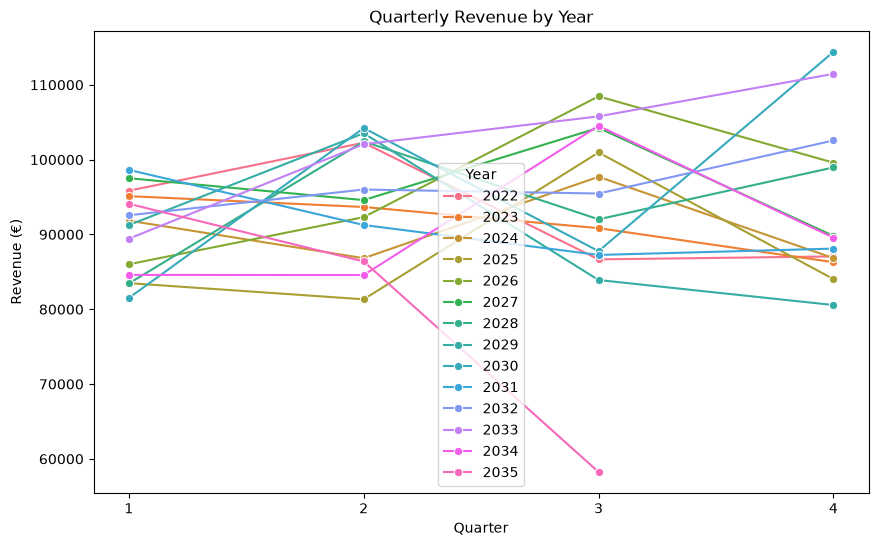

In [72]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=quarterly_sales,
    x="quarter",
    y="revenue",
    hue="year",
    marker="o"
)

plt.title("Quarterly Revenue by Year")
plt.xlabel("Quarter")
plt.ylabel("Revenue (€)")
plt.xticks([1, 2, 3, 4])
plt.legend(title="Year")
plt.show()

Key findings:
- Quarterly revenue varies noticeably across the year, suggesting that sales performance is influenced by seasonal demand and timing effects.
- Q3 and Q4 often produce stronger revenue than Q1 and Q2 in several years, indicating that the business tends to perform better in the second half of the year.
- Order volume remains relatively stable by quarter, while revenue changes because AOV shifts across periods. This suggests that changes in spending per order are an important driver of quarterly performance.
- The sharp drop in the final quarter of the dataset indicates a possible period of weaker demand or lower transaction value, which should be investigated further.


*Day-of-week Performance Analysis*

In [74]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = (
    df.groupby("day_of_week")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        AOV=("revenue", "mean")
    )
)

day_sales = day_sales.reindex(day_order)  # Reorder the index to match the desired order of days
day_sales 

,revenue,orders,AOV
day_of_week,,,
Monday,729466.69,714,1021.662031
Tuesday,742856.04,714,1040.414622
Wednesday,727338.13,714,1018.680854
Thursday,694328.93,714,972.449482
Friday,730978.26,714,1023.779076
Saturday,758305.90,715,1060.567692
Sunday,726501.79,715,1016.086420


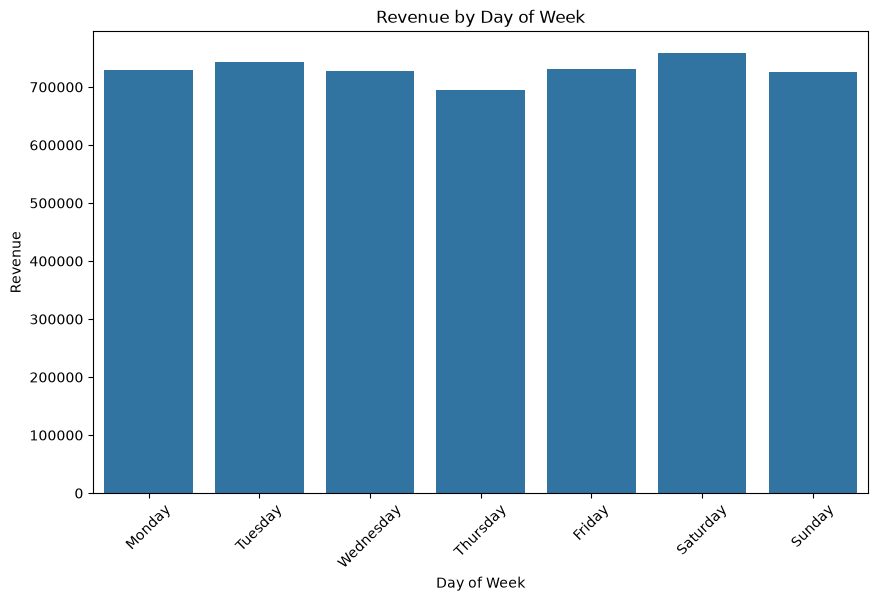

In [76]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=day_sales.index,
    y=day_sales["revenue"]
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Key findings:
- Revenue and order volume are fairly consistent across weekdays, with only modest differences between days.
- Saturday shows the strongest performance, with the highest revenue and the highest AOV, suggesting that customers spend more on weekend purchases.
- Thursday is the weakest day in terms of revenue and AOV, indicating lower customer spending compared with other days.
- Overall, the business does not show extreme weekday swings, but weekend demand is slightly stronger and may be a good target for promotions or campaigns.


**Session 5: Discount Analysis**

In [78]:
bins = [-0.01, 0, 0.05, 0.10, 0.20, 1]

labels = [
    "No discount",
    "1–5%",
    "5–10%",
    "10–20%",
    "20%+"
]

df["discount_band"] = pd.cut(
    df["discount"],
    bins=bins,
    labels=labels
)

df['discount_band'].value_counts()

discount_band
20%+           2198
10–20%         1401
1–5%            680
5–10%           653
No discount      68
Name: count, dtype: int64

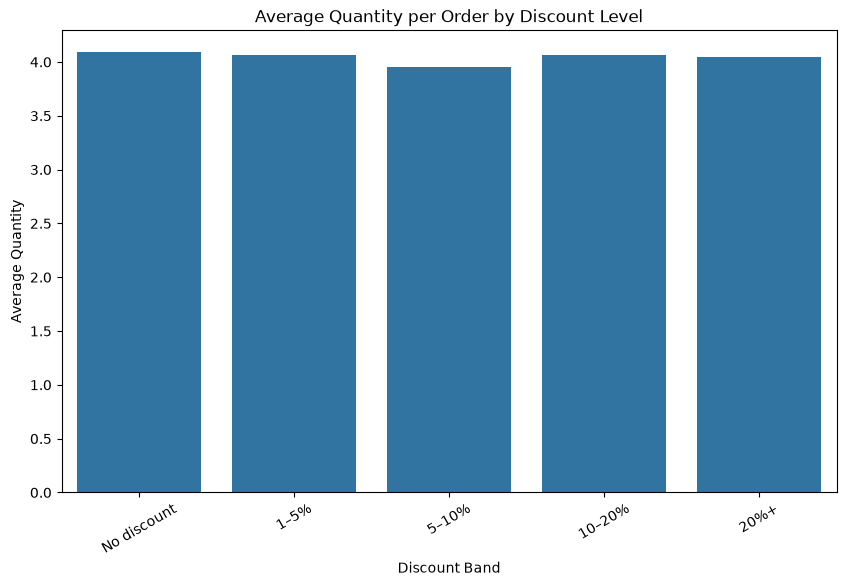

In [79]:
discount_quantity = (
    df.groupby("discount_band", observed=False)["quantity"]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_quantity.index,
    y=discount_quantity.values
)

plt.title("Average Quantity per Order by Discount Level")
plt.xlabel("Discount Band")
plt.ylabel("Average Quantity")
plt.xticks(rotation=30)
plt.show()

In [80]:
discount_aov = (
    df.groupby("discount_band", observed=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
)

discount_aov["AOV"] = (
    discount_aov["revenue"] /
    discount_aov["orders"]
)

discount_aov

,revenue,orders,AOV
discount_band,,,
No discount,81686.86,68,1201.277353
1–5%,822084.33,680,1208.947544
5–10%,720633.71,653,1103.573828
10–20%,1482197.03,1401,1057.956481
20%+,2003173.81,2198,911.362061


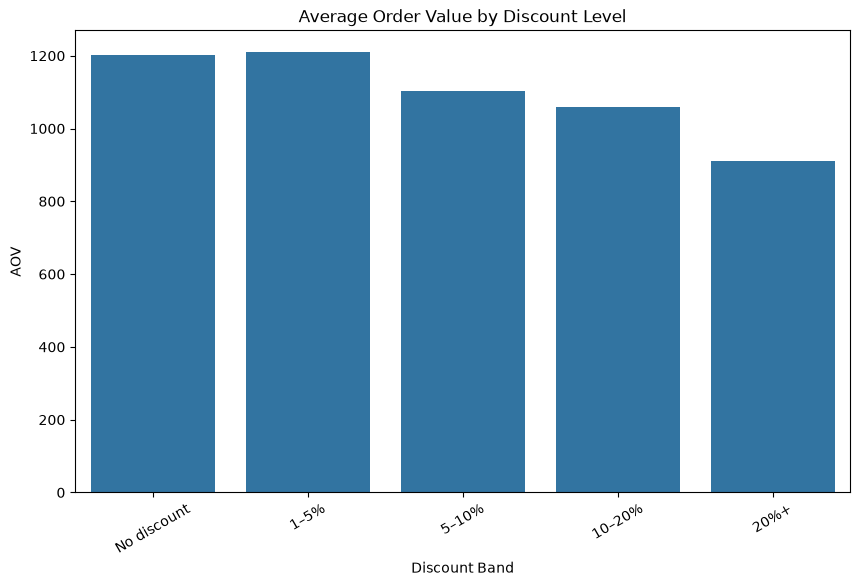

In [81]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_aov.index,
    y=discount_aov["AOV"]
)

plt.title("Average Order Value by Discount Level")
plt.xlabel("Discount Band")
plt.ylabel("AOV")
plt.xticks(rotation=30)
plt.show()

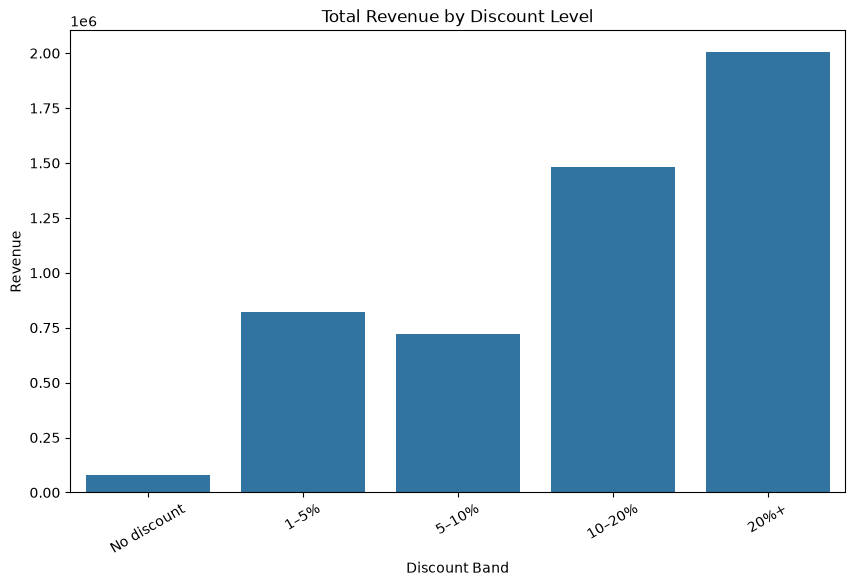

In [82]:
discount_revenue = (
    df.groupby("discount_band", observed=False)["revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=discount_revenue.index,
    y=discount_revenue.values
)

plt.title("Total Revenue by Discount Level")
plt.xlabel("Discount Band")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

**Session 6: Customer Satisfaction Analysis**

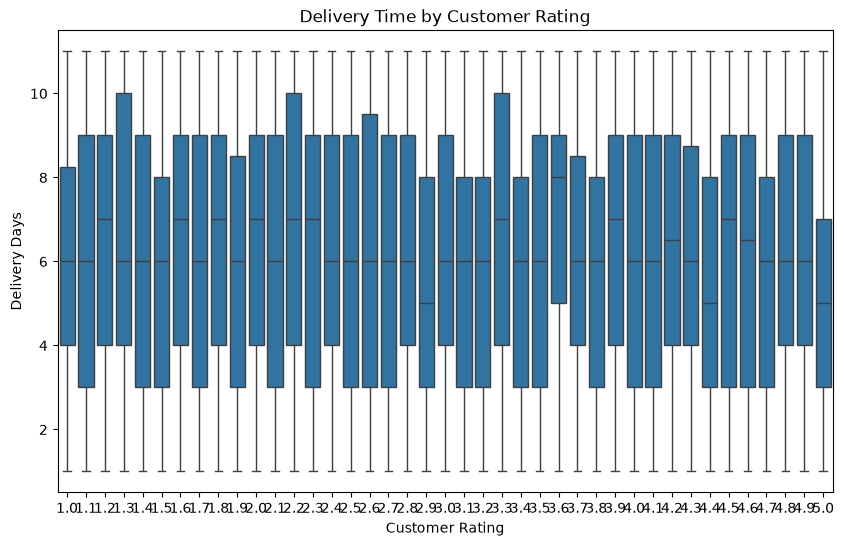

In [85]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="customer_rating",
    y="delivery_days"
)

plt.title("Delivery Time by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Delivery Days")
plt.show()

In [86]:
df[["delivery_days", "customer_rating"]].corr()

,delivery_days,customer_rating
delivery_days,1.000000,-0.017625
customer_rating,-0.017625,1.000000


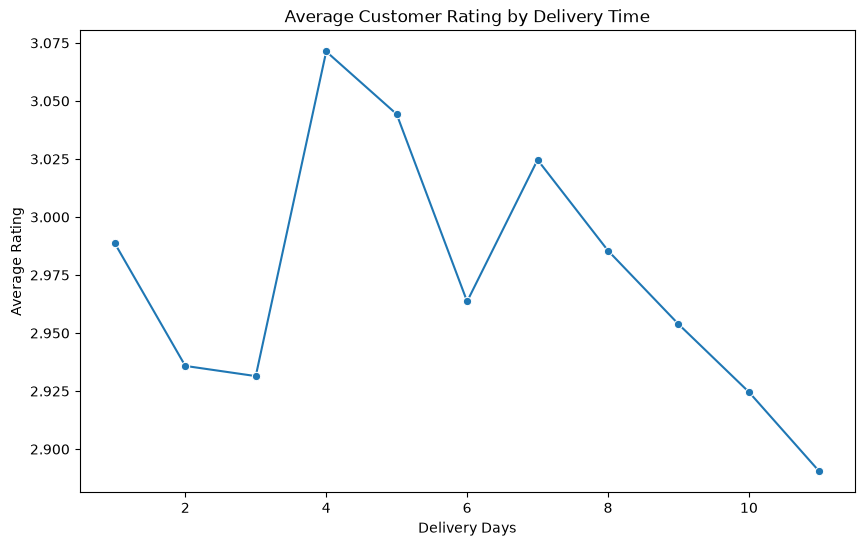

In [87]:
delivery_rating = (
    df.groupby("delivery_days")["customer_rating"]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=delivery_rating.index,
    y=delivery_rating.values,
    marker="o"
)

plt.title("Average Customer Rating by Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.show()

In [88]:
region_customer_experience = (
    df.groupby("region")
    .agg(
        avg_rating=("customer_rating", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .sort_values("avg_rating")
)

region_customer_experience

,avg_rating,avg_delivery_days,orders,revenue
region,,,,
West,2.961521,6.082234,1289,1345582.16
South,2.967798,6.173013,1208,1246640.90
East,2.973187,6.104319,1227,1236044.23
North,2.993182,6.118339,1276,1281508.45
